In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cattle-weight-detection-model-dataset-12k/www.acmeai.tech BMGF - LivestockWeight - CV.pdf
/kaggle/input/cattle-weight-detection-model-dataset-12k/www.acmeai.tech Dataset - BMGF-LivestockWeight-CV/Readme.md
/kaggle/input/cattle-weight-detection-model-dataset-12k/www.acmeai.tech Dataset - BMGF-LivestockWeight-CV/Vector/B2/Side/data/Side/COCO_Side.json
/kaggle/input/cattle-weight-detection-model-dataset-12k/www.acmeai.tech Dataset - BMGF-LivestockWeight-CV/Vector/B2/Side/data/Side/images/13.0_s_129_4.2_F.jpg
/kaggle/input/cattle-weight-detection-model-dataset-12k/www.acmeai.tech Dataset - BMGF-LivestockWeight-CV/Vector/B2/Side/data/Side/images/148.0_s_239_5.6_F.jpg
/kaggle/input/cattle-weight-detection-model-dataset-12k/www.acmeai.tech Dataset - BMGF-LivestockWeight-CV/Vector/B2/Side/data/Side/images/175.0_s_156_8.0_F.jpg
/kaggle/input/cattle-weight-detection-model-dataset-12k/www.acmeai.tech Dataset - BMGF-LivestockWeight-CV/Vector/B2/Side/data/Side/images/101.0_s_199_3.0_F

In [2]:
# Cell 1: Import libraries and explore dataset structure
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

In [3]:
import os

# Check dataset structure only for B3 Side and Rear
dataset_path = "/kaggle/input/cattle-weight-detection-model-dataset-12k/"
b3_side_path = os.path.join(dataset_path, "www.acmeai.tech Dataset - BMGF-LivestockWeight-CV", "Vector", "B3", "Side", "data", "images")
b3_rear_path = os.path.join(dataset_path, "www.acmeai.tech Dataset - BMGF-LivestockWeight-CV", "Vector", "B3", "Rear", "data", "images")

print("Dataset contents (B3 Side and Rear only):")

for subfolder_path in [b3_side_path, b3_rear_path]:
    if os.path.exists(subfolder_path):
        print(f"{os.path.basename(subfolder_path)}/")
        files = os.listdir(subfolder_path)
        for file in files[:5]:  # Show first 5 files
            print(f"  {file}")
        if len(files) > 5:
            print(f"  ... and {len(files)-5} more files")
    else:
        print(f"{subfolder_path} not found.")


Dataset contents (B3 Side and Rear only):
images/
  409_s_99_F.jpg
  166_s_140_F.jpg
  386_s_163_F.jpg
  289_s_237_F.jpg
  204_s_150_F.jpg
  ... and 2598 more files
images/
  15_r_85_F.jpg
  83_r_87_F.jpg
  117_r_174_F.jpg
  188_r_148_F.jpg
  82_r_123_M.jpg
  ... and 2596 more files


In [4]:
import os
import pandas as pd

def parse_cattle_filename(filename):
    """
    Parse cattle image filename to extract labels.
    Expected format: Id_view_weight_gender.jpg
    Example: 409_s_99_F.jpg
    """
    
    # Remove file extension
    name = filename.replace('.jpg', '').replace('.jpeg', '').replace('.png', '')
    parts = name.split('_')
    
    result = {
        'filename': filename,
        'id': None,
        'view': None,
        'weight': None,
        'gender': None,
        'valid': False
    }
    
    try:
        if len(parts) == 4:
            id_part = parts[0]
            view_part = parts[1]
            weight_part = parts[2]
            gender_part = parts[3]
            
            # Validate ID
            if not id_part.strip():
                raise ValueError("ID part is empty")
            
            # Validate view
            valid_views = ['s', 'r', 'f', 'side', 'rear', 'front']
            if view_part.lower() not in valid_views:
                print(f"Warning: Unexpected view '{view_part}' in {filename}")
            
            # Validate weight
            weight_val = float(weight_part)
            if weight_val <= 0:
                raise ValueError("Weight must be positive")
            
            # Validate gender
            if gender_part.upper() not in ['M', 'F']:
                raise ValueError(f"Gender must be M or F, got '{gender_part}'")
            
            # All validations passed
            result['id'] = id_part
            result['view'] = view_part.lower()
            result['weight'] = weight_val
            result['gender'] = gender_part.upper()
            result['valid'] = True
            
        else:
            raise ValueError(f"Expected 4 parts separated by underscores, got {len(parts)}")
            
    except (ValueError, IndexError) as e:
        print(f"Could not parse filename: {filename} - {e}")
        result['valid'] = False
    
    return result


def create_cattle_dataset_df_b3(dataset_path):
    """
    Create a pandas DataFrame for B3 Side and Rear images only.
    """
    
    data = []
    invalid_files = []
    
    # Define B3 Side and Rear paths
    b3_side_path = os.path.join(dataset_path, "www.acmeai.tech Dataset - BMGF-LivestockWeight-CV", "Vector", "B3", "Side", "data", "images")
    b3_rear_path = os.path.join(dataset_path, "www.acmeai.tech Dataset - BMGF-LivestockWeight-CV", "Vector", "B3", "Rear", "data", "images")
    
    for folder_path, view_folder in [(b3_side_path, 'Side'), (b3_rear_path, 'Rear')]:
        if os.path.exists(folder_path):
            files = os.listdir(folder_path)
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')) and '___fuse' not in file:
                    file_path = os.path.join(folder_path, file)
                    
                    # Parse filename
                    parsed = parse_cattle_filename(file)
                    
                    if parsed['valid']:
                        parsed['folder'] = view_folder
                        parsed['full_path'] = file_path
                        parsed['batch_folder'] = 'B3'
                        data.append(parsed)
                    else:
                        invalid_files.append(file)
        else:
            print(f"Path not found: {folder_path}")
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    return df, invalid_files


def analyze_dataset(df):
    """Analyze the dataset and print statistics."""
    
    print("=" * 60)
    print("B3 SIDE & REAR DATASET ANALYSIS")
    print("=" * 60)
    
    if len(df) == 0:
        print("No valid data found!")
        return
    
    print(f"\nTotal valid images: {len(df)}")
    print(f"Unique cattle IDs: {df['id'].nunique()}")
    
    # Gender distribution
    print(f"\n🐄 GENDER DISTRIBUTION")
    gender_counts = df['gender'].value_counts()
    for gender, count in gender_counts.items():
        print(f"  {gender}: {count} images ({(count/len(df))*100:.1f}%)")
    
    # View distribution
    print(f"\n👁️ VIEW DISTRIBUTION")
    view_counts = df['view'].value_counts()
    for view, count in view_counts.items():
        print(f"  {view}: {count} images ({(count/len(df))*100:.1f}%)")
    
    # Weight statistics
    weights = df['weight']
    print(f"\n⚖️ WEIGHT STATISTICS")
    print(f"Weight range: {weights.min()} - {weights.max()} kg")
    print(f"Average weight: {weights.mean():.1f} kg")
    print(f"Median weight: {weights.median():.1f} kg")
    print(f"Standard deviation: {weights.std():.1f} kg")
    
    # Sample data
    print(f"\n📋 SAMPLE DATA")
    print(df[['id', 'view', 'weight', 'gender']].head(10))


def main():
    dataset_path = "/kaggle/input/cattle-weight-detection-model-dataset-12k/"
    
    print("📁 Processing B3 Side and Rear dataset...")
    
    # Create DataFrame
    df, invalid_files = create_cattle_dataset_df_b3(dataset_path)
    
    # Analyze
    analyze_dataset(df)
    
    # Save DataFrame
    if len(df) > 0:
        output_path = '/kaggle/working/cattle_b3_side_rear_dataset.csv'
        df.to_csv(output_path, index=False)
        print(f"\n💾 Dataset saved to: {output_path}")
    else:
        print("No valid data to save.")
    
    # Show invalid files if any
    if invalid_files:
        print(f"\n❌ INVALID FILES ({len(invalid_files)} total)")
        for i, f in enumerate(invalid_files[:10]):
            print(f"  {i+1}. {f}")
        if len(invalid_files) > 10:
            print(f"  ... and {len(invalid_files)-10} more")
    
    return df, invalid_files


# Run main function
if __name__ == "__main__":
    df, invalid_files = main()


📁 Processing B3 Side and Rear dataset...
B3 SIDE & REAR DATASET ANALYSIS

Total valid images: 5204
Unique cattle IDs: 514

🐄 GENDER DISTRIBUTION
  F: 4316 images (82.9%)
  M: 888 images (17.1%)

👁️ VIEW DISTRIBUTION
  s: 2603 images (50.0%)
  r: 2601 images (50.0%)

⚖️ WEIGHT STATISTICS
Weight range: 36.0 - 621.0 kg
Average weight: 156.9 kg
Median weight: 152.0 kg
Standard deviation: 47.9 kg

📋 SAMPLE DATA
    id view  weight gender
0  409    s    99.0      F
1  166    s   140.0      F
2  386    s   163.0      F
3  289    s   237.0      F
4  204    s   150.0      F
5  271    s   174.0      F
6  238    s   111.0      M
7  124    s   129.0      F
8  334    s   214.0      F
9    4    s    77.0      F

💾 Dataset saved to: /kaggle/working/cattle_b3_side_rear_dataset.csv


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Using device: cuda
GPU Name: Tesla P100-PCIE-16GB
GPU Memory: 15.9 GB


Cell 2: Load and Analyze Dataset

Dataset columns: ['filename', 'id', 'view', 'weight', 'gender', 'valid', 'folder', 'full_path', 'batch_folder']

First few rows:
          filename   id view  weight gender  valid folder  \
0   409_s_99_F.jpg  409    s    99.0      F   True   Side   
1  166_s_140_F.jpg  166    s   140.0      F   True   Side   
2  386_s_163_F.jpg  386    s   163.0      F   True   Side   
3  289_s_237_F.jpg  289    s   237.0      F   True   Side   
4  204_s_150_F.jpg  204    s   150.0      F   True   Side   

                                           full_path batch_folder  
0  /kaggle/input/cattle-weight-detection-model-da...           B3  
1  /kaggle/input/cattle-weight-detection-model-da...           B3  
2  /kaggle/input/cattle-weight-detection-model-da...           B3  
3  /kaggle/input/cattle-weight-detection-model-da...           B3  
4  /kaggle/input/cattle-weight-detection-model-da...           B3  

Training with 5204 images with weight labels

=== LABELED DATASET ANALYSIS (WEIGHT in KG) ===
W

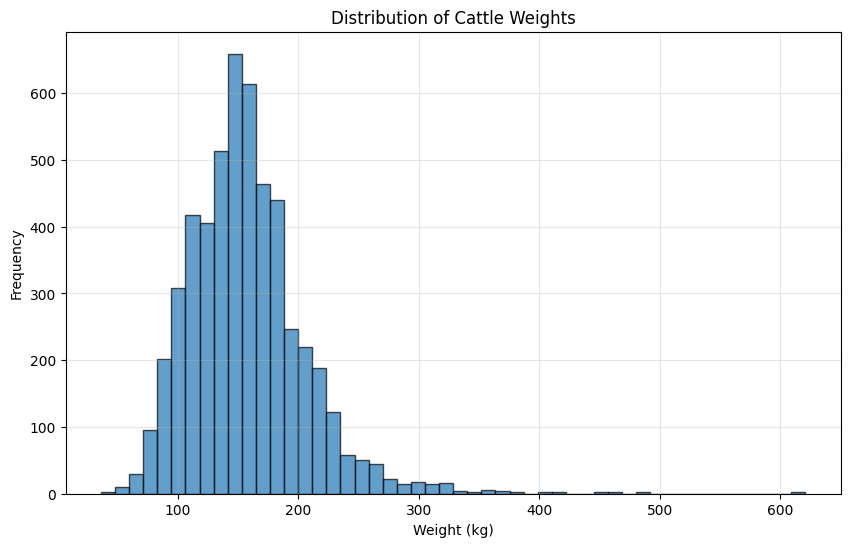

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/kaggle/working/cattle_b3_side_rear_dataset.csv')

# Check the structure of your dataset
print("Dataset columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Filter for images with weight labels
weight_df = df[df['weight'].notna()].copy()
print(f"\nTraining with {len(weight_df)} images with weight labels")

# Analyze the labeled dataset (weight in kg)
print("\n=== LABELED DATASET ANALYSIS (WEIGHT in KG) ===")
print(f"Weight range: {weight_df['weight'].min():.1f} - {weight_df['weight'].max():.1f} kg")
print(f"Average weight: {weight_df['weight'].mean():.1f} kg")
print(f"Standard deviation: {weight_df['weight'].std():.1f} kg")

# Plot weight distribution
plt.figure(figsize=(10, 6))
plt.hist(weight_df['weight'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Cattle Weights')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# CRITICAL: Normalize your target values to prevent NaN loss
print("=== TARGET NORMALIZATION ===")
print(f"Original weight range: {weight_df['weight'].min():.1f} - {weight_df['weight'].max():.1f} kg")

# Calculate normalization parameters
weight_mean = weight_df['weight'].mean()
weight_std = weight_df['weight'].std()

print(f"Weight mean: {weight_mean:.2f} kg")
print(f"Weight std: {weight_std:.2f} kg")

# Normalize weights (z-score normalization)
weight_df['weight_normalized'] = (weight_df['weight'] - weight_mean) / weight_std

print(f"Normalized range: {weight_df['weight_normalized'].min():.3f} - {weight_df['weight_normalized'].max():.3f}")

# Save normalization parameters for later use
normalization_params = {
    'mean': weight_mean,
    'std': weight_std
}

print("✅ Target normalization complete!")

=== TARGET NORMALIZATION ===
Original weight range: 36.0 - 621.0 kg
Weight mean: 156.94 kg
Weight std: 47.94 kg
Normalized range: -2.523 - 9.680
✅ Target normalization complete!


Cell 3: Check Data Quality

Sample of existing files: 10
Missing files in sample: 0


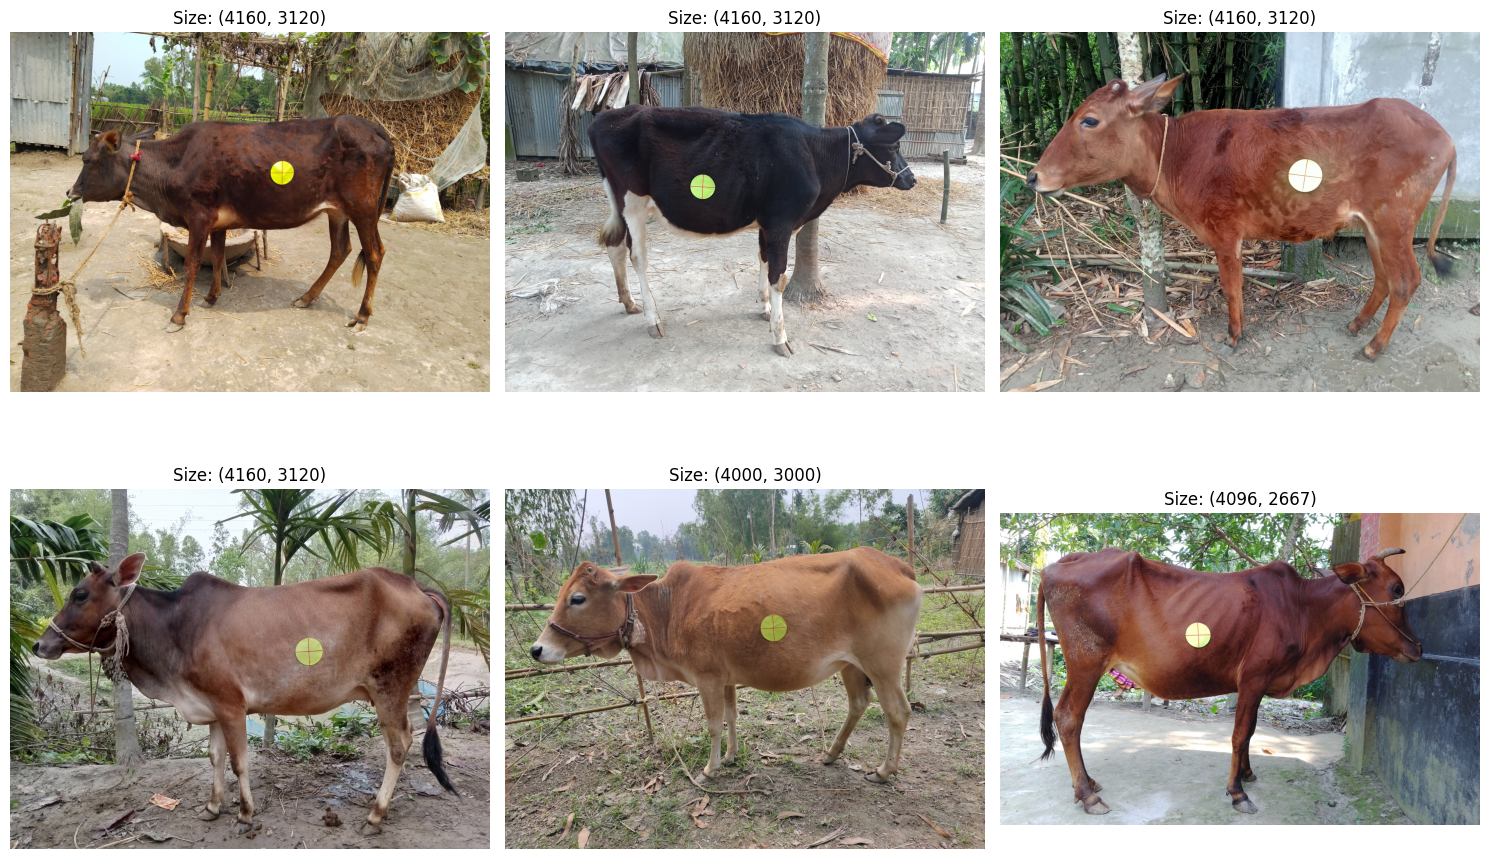

In [8]:
import os
from PIL import Image

# Check for any missing image files
missing_files = []
sample_images = []

for idx, row in weight_df.head(10).iterrows():
    if os.path.exists(row['full_path']):
        sample_images.append(row['full_path'])
    else:
        missing_files.append(row['full_path'])

print(f"Sample of existing files: {len(sample_images)}")
print(f"Missing files in sample: {len(missing_files)}")

# Display a few sample images
if sample_images:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, img_path in enumerate(sample_images[:6]):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"Size: {img.size}")
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error loading\n{str(e)}", 
                        ha='center', va='center', transform=axes[i].transAxes)
    
    plt.tight_layout()
    plt.show()

Cell 4: Train/Val/Test Split

In [10]:
from sklearn.model_selection import train_test_split

print("Creating train/validation/test splits...")

# Check if we have categorical columns for stratified split
available_columns = weight_df.columns.tolist()
print(f"Available columns: {available_columns}")

if 'gender' in available_columns and weight_df['gender'].nunique() > 1:
    print("Using stratified split based on gender")
    train_df, temp_df = train_test_split(
        weight_df, test_size=0.3, random_state=42, 
        stratify=weight_df['gender']
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, random_state=42,
        stratify=temp_df['gender']
    )
else:
    print("Using random split")
    train_df, temp_df = train_test_split(
        weight_df, test_size=0.3, random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, random_state=42
    )

print(f"\nDataset split:")
print(f"Train: {len(train_df)} images ({len(train_df)/len(weight_df)*100:.1f}%)")
print(f"Val: {len(val_df)} images ({len(val_df)/len(weight_df)*100:.1f}%)")
print(f"Test: {len(test_df)} images ({len(test_df)/len(weight_df)*100:.1f}%)")

# Check weight distribution in each split
print(f"\nWeight statistics:")
print(f"Train - Mean: {train_df['weight'].mean():.1f}, Std: {train_df['weight'].std():.1f}")
print(f"Val - Mean: {val_df['weight'].mean():.1f}, Std: {val_df['weight'].std():.1f}")
print(f"Test - Mean: {test_df['weight'].mean():.1f}, Std: {test_df['weight'].std():.1f}")

Creating train/validation/test splits...
Available columns: ['filename', 'id', 'view', 'weight', 'gender', 'valid', 'folder', 'full_path', 'batch_folder', 'weight_normalized']
Using stratified split based on gender

Dataset split:
Train: 3642 images (70.0%)
Val: 781 images (15.0%)
Test: 781 images (15.0%)

Weight statistics:
Train - Mean: 156.4, Std: 47.4
Val - Mean: 156.7, Std: 48.6
Test - Mean: 159.8, Std: 49.6


In [ ]:
##Cell 5: Define Data Transforms

In [11]:
# Define data transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Data transforms defined successfully!")
print("Train transform includes:")
print("- Resize to 224x224")
print("- Random horizontal flip")
print("- Random rotation (±10 degrees)")
print("- Color jitter")
print("- Random resized crop")
print("- Normalization")

Data transforms defined successfully!
Train transform includes:
- Resize to 224x224
- Random horizontal flip
- Random rotation (±10 degrees)
- Color jitter
- Random resized crop
- Normalization


In [ ]:
###Cell6: Create Dataset Class

In [12]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class CattleWeightDataset(Dataset):
    def __init__(self, df, transform=None, use_normalized=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.use_normalized = use_normalized
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        try:
            image = Image.open(row['full_path']).convert('RGB')
        except Exception as e:
            print(f"Error loading image {row['full_path']}: {e}")
            # Return a black image as fallback
            image = Image.new('RGB', (224, 224), color='black')
            
        if self.transform:
            image = self.transform(image)
        
        # Get weight (use normalized version)
        if self.use_normalized:
            weight = torch.tensor(row['weight_normalized'], dtype=torch.float32)
        else:
            weight = torch.tensor(row['weight'], dtype=torch.float32)
        
        return image, weight

# Test the dataset
print("Testing updated dataset creation...")
test_dataset = CattleWeightDataset(train_df.head(5), val_transform)
sample_img, sample_weight = test_dataset[0]
print(f"Sample image shape: {sample_img.shape}")
print(f"Sample normalized weight: {sample_weight.item():.3f}")
print("✅ Updated dataset class created successfully!")

Testing updated dataset creation...
Sample image shape: torch.Size([3, 224, 224])
Sample normalized weight: -0.270
✅ Updated dataset class created successfully!


In [ ]:
####Cell 7: Create Data Loaders

In [13]:
from torch.utils.data import DataLoader

# Create datasets
train_dataset = CattleWeightDataset(train_df, train_transform)
val_dataset = CattleWeightDataset(val_df, val_transform)
test_dataset = CattleWeightDataset(test_df, val_transform)

# Batch size - adjust based on your GPU memory
batch_size = 32
print(f"Using batch size: {batch_size}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\nData loaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Test data loading
print("\nTesting data loading...")
for batch_idx, (images, weights) in enumerate(train_loader):
    print(f"Batch {batch_idx+1}: Images shape {images.shape}, Weights shape {weights.shape}")
    print(f"Sample weights: {weights[:5].numpy()}")
    break

Using batch size: 32

Data loaders created:
Train batches: 114
Val batches: 25
Test batches: 25

Testing data loading...
Batch 1: Images shape torch.Size([32, 3, 224, 224]), Weights shape torch.Size([32])
Sample weights: [-0.35334    -0.89566725  0.39757463 -0.7705148   0.5853033 ]


In [ ]:
###Cell 8: Define Model

In [14]:
import torch.nn as nn
import torchvision.models as models

class CattleWeightModel(nn.Module):
    def __init__(self, backbone='resnet18'):
        super(CattleWeightModel, self).__init__()
        
        # Load pre-trained backbone
        if backbone == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(pretrained=True)
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
        elif backbone == 'resnet50':
            self.backbone = models.resnet50(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        else:
            # Default to ResNet18 for faster training
            self.backbone = models.resnet18(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        
        # Improved regression head with better initialization
        self.regressor = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
        
        # Initialize weights properly
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.regressor.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        features = self.backbone(x)
        weight = self.regressor(features)
        return weight.squeeze()

# Initialize model
model = CattleWeightModel('resnet18').to(device)
print(f"✅ Improved model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 222MB/s]


✅ Improved model initialized with 11,324,993 parameters


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score
import torch

def train_epoch(model, loader, criterion, optimizer, device, clip_grad=True):
    model.train()
    total_loss = 0
    predictions = []
    targets = []
    
    for batch_idx, (images, weights) in enumerate(loader):
        images, weights = images.to(device), weights.to(device)
        
        # Check for NaN in inputs
        if torch.isnan(images).any() or torch.isnan(weights).any():
            print(f"Warning: NaN detected in batch {batch_idx}")
            continue
        
        optimizer.zero_grad()
        outputs = model(images)
        
        # Check for NaN in outputs
        if torch.isnan(outputs).any():
            print(f"Warning: NaN in model outputs at batch {batch_idx}")
            continue
            
        loss = criterion(outputs, weights)
        
        # Check for NaN loss
        if torch.isnan(loss):
            print(f"Warning: NaN loss at batch {batch_idx}")
            continue
            
        loss.backward()
        
        # Gradient clipping to prevent explosion
        if clip_grad:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        predictions.extend(outputs.detach().cpu().numpy())
        targets.extend(weights.detach().cpu().numpy())
        
        # Print progress every 50 batches
        if batch_idx % 50 == 0:
            print(f'  Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}')
    
    if len(predictions) == 0:
        print("ERROR: No valid predictions in this epoch!")
        return float('inf'), float('inf')
    
    avg_loss = total_loss / len(loader)
    mae = mean_absolute_error(targets, predictions)
    return avg_loss, mae

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for images, weights in loader:
            images, weights = images.to(device), weights.to(device)
            
            # Skip batches with NaN
            if torch.isnan(images).any() or torch.isnan(weights).any():
                continue
                
            outputs = model(images)
            
            # Skip if outputs are NaN
            if torch.isnan(outputs).any():
                continue
                
            loss = criterion(outputs, weights)
            
            if torch.isnan(loss):
                continue
            
            total_loss += loss.item()
            predictions.extend(outputs.cpu().numpy())
            targets.extend(weights.cpu().numpy())
    
    if len(predictions) == 0:
        return float('inf'), float('inf'), -1, [], []
    
    avg_loss = total_loss / len(loader)
    mae = mean_absolute_error(targets, predictions)
    r2 = r2_score(targets, predictions)
    return avg_loss, mae, r2, predictions, targets

print("✅ Updated training functions with NaN protection and weight variable names!")

✅ Updated training functions with NaN protection and weight variable names!


In [16]:
import torch.optim as optim
import torch.nn as nn

# IMPROVED Training parameters
num_epochs = 30
learning_rate = 1e-5  # REDUCED learning rate
weight_decay = 1e-5   # REDUCED weight decay

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# More conservative learning rate schedule
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Initialize tracking variables
best_val_mae = float('inf')
train_losses = []
val_losses = []
train_maes = []
val_maes = []

print(f"✅ IMPROVED Training setup complete!")
print(f"Epochs: {num_epochs}")
print(f"Learning rate: {learning_rate} (REDUCED)")
print(f"Weight decay: {weight_decay} (REDUCED)")
print(f"Gradient clipping: ENABLED")
print(f"Target normalization: ENABLED")

✅ IMPROVED Training setup complete!
Epochs: 30
Learning rate: 1e-05 (REDUCED)
Weight decay: 1e-05 (REDUCED)
Gradient clipping: ENABLED
Target normalization: ENABLED


In [1]:
print("=== TRAINING STARTED ===")
print(f"Training on {device}")
print(f"Total epochs: {num_epochs}")
print("-" * 50)

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}:')
    
    # Train
    train_loss, train_mae = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_mae, val_r2, val_preds, val_targets = validate(model, val_loader, criterion, device)
    
    # Update learning rate
    scheduler.step()
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_maes.append(train_mae)
    val_maes.append(val_mae)
    
    # Save best model
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_mae': val_mae,
            'val_r2': val_r2,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_maes': train_maes,
            'val_maes': val_maes
        }, '/kaggle/working/best_cattle_weight_model.pth')
        print(f" ⭐ NEW BEST MODEL SAVED! MAE: {val_mae:.3f} kg")
    
    # Print progress
    print(f'  Train Loss: {train_loss:.4f}, Train MAE: {train_mae:.3f} kg')
    print(f'  Val Loss: {val_loss:.4f}, Val MAE: {val_mae:.3f} kg, Val R²: {val_r2:.3f}')
    print(f'  LR: {scheduler.get_last_lr()[0]:.6f}')
    
    # Early stopping check (optional)
    if epoch > 10 and val_mae > best_val_mae * 1.1:
        print(f"  Warning: Val MAE hasn't improved for several epochs")

print(f"\n🎉 TRAINING COMPLETED!")
print(f"Best validation MAE: {best_val_mae:.3f} kg")

=== TRAINING STARTED ===


NameError: name 'device' is not defined

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load normalization params (replace with your actual values from training)
normalization_params = {
    'mean': 156.4,  # <-- Replace with your actual mean 156.4,  
    'std': 47.4     # <-- Replace with your actual std Std: 47.4
}
# If you saved these in a file, load them here.

# Load model
model = CattleWeightModel('resnet18').to(device)
checkpoint = torch.load('/kaggle/working/best_cattle_weight_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("✅ Model loaded and ready for inference!")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/best_cattle_weight_model.pth'

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Add normalization if you used it during training, e.g.:
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
test_image_dir = '/kaggle/input/your-test-images/'  # Update this path
test_image_files = [f for f in os.listdir(test_image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

results = []

for img_name in test_image_files:
    img_path = os.path.join(test_image_dir, img_name)
    img = Image.open(img_path).convert('RGB')
    img_tensor = val_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_norm = model(img_tensor).item()
        # Inverse normalization
        pred_weight = pred_norm * normalization_params['std'] + normalization_params['mean']
    results.append({'filename': img_name, 'predicted_weight_kg': pred_weight})
    print(f"{img_name}: Predicted weight = {pred_weight:.2f} kg")

In [ ]:
results_df = pd.DataFrame(results)
results_df.to_csv('/kaggle/working/cattle_weight_predictions.csv', index=False)
print("✅ Predictions saved to /kaggle/working/cattle_weight_predictions.csv")

In [ ]:
import matplotlib.pyplot as plt

for i, row in results_df.head(6).iterrows():
    img = Image.open(os.path.join(test_image_dir, row['filename']))
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"{row['filename']}\nPred: {row['predicted_weight_kg']:.1f} kg")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# # Kaggle Cattle Weight Detection Model Setup Guide

# ## Step 1: Create New Kaggle Notebook

# 1. **Go to Kaggle** → [kaggle.com](https://www.kaggle.com)
# 2. **Click "Code"** → "New Notebook"
# 3. **Choose "Notebook"** (not Script)
# 4. **Set Accelerator** to "GPU P100" or "GPU T4 x2" (free tier)

# ## Step 2: Add Dataset to Notebook

# 1. **Click "Add Data"** in the right sidebar
# 2. **Search for:** `sadhliroomyprime/cattle-weight-detection-model-dataset-12k`
# 3. **Click "Add"** to attach the dataset
# 4. **Note the dataset path:** `/kaggle/input/cattle-weight-detection-model-dataset-12k/`

# ## Step 3: Initial Setup and Data Exploration

# ```python
# # Cell 1: Import libraries and explore dataset structure
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# import cv2
# from PIL import Image
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# import torchvision.transforms as transforms
# import torchvision.models as models

# # Check dataset structure
# dataset_path = "/kaggle/input/cattle-weight-detection-model-dataset-12k/"
# print("Dataset contents:")
# for root, dirs, files in os.walk(dataset_path):
#     level = root.replace(dataset_path, '').count(os.sep)
#     indent = ' ' * 2 * level
#     print(f"{indent}{os.path.basename(root)}/")
#     subindent = ' ' * 2 * (level + 1)
#     for file in files[:5]:  # Show first 5 files
#         print(f"{subindent}{file}")
#     if len(files) > 5:
#         print(f"{subindent}... and {len(files)-5} more files")
# ```

# ## Step 4: Data Analysis and Preprocessing

# ```python
# # Cell 2: Analyze the dataset structure and extract weight information
# def analyze_dataset_structure(dataset_path):
#     """Analyze the structure of the cattle dataset"""
#     image_files = []
#     for root, dirs, files in os.walk(dataset_path):
#         for file in files:
#             if file.lower().endswith(('.jpg', '.jpeg', '.png')):
#                 image_files.append(os.path.join(root, file))
    
#     print(f"Total images found: {len(image_files)}")
    
#     # Check if there's a CSV file with labels
#     csv_files = []
#     for root, dirs, files in os.walk(dataset_path):
#         for file in files:
#             if file.lower().endswith('.csv'):
#                 csv_files.append(os.path.join(root, file))
    
#     print(f"CSV files found: {len(csv_files)}")
#     for csv_file in csv_files:
#         print(f"  - {csv_file}")
        
#     return image_files, csv_files

# image_files, csv_files = analyze_dataset_structure(dataset_path)

# # Since no CSV files, let's analyze the filename patterns
# print("\n=== FILENAME ANALYSIS ===")
# print("Sample filenames:")
# for i, img_path in enumerate(image_files[:10]):
#     filename = os.path.basename(img_path)
#     print(f"{i+1:2d}. {filename}")

# # Analyze folder structure
# print("\n=== FOLDER STRUCTURE ===")
# folder_structure = {}
# for img_path in image_files:
#     folder = os.path.dirname(img_path).replace(dataset_path, '').strip('/')
#     if folder not in folder_structure:
#         folder_structure[folder] = []
#     folder_structure[folder].append(os.path.basename(img_path))

# for folder, files in folder_structure.items():
#     print(f"{folder}: {len(files)} images")
#     if files:
#         print(f"  Sample: {files[0]}")
# ```

# ## Step 5: Copy and Adapt the Model Code

# ```python
# # Cell 3: Copy the enhanced model code (paste your entire model code here)
# # [Copy the entire code from your paste.txt file]

# # Make sure to modify the dataset paths for Kaggle environment
# ```

# ## Step 6: Create Custom Dataset Loader

# ```python
# # Cell 4: Create dataset loader adapted for Kaggle dataset
# class KaggleCattleDataset(Dataset):
#     def __init__(self, image_files, labels_df=None, transform=None):
#         self.image_files = image_files
#         self.labels_df = labels_df
#         self.transform = transform
        
#     def __len__(self):
#         return len(self.image_files)
    
#     def __getitem__(self, idx):
#         image_path = self.image_files[idx]
#         image = Image.open(image_path).convert('RGB')
        
#         if self.transform:
#             image = self.transform(image)
        
#         # Extract weight from filename or CSV
#         # This will need to be adapted based on the actual dataset structure
#         weight = self.extract_weight_from_path(image_path)
        
#         return {
#             'image': image,
#             'weight': weight,
#             'path': image_path
#         }
    
#     def extract_weight_from_path(self, image_path):
#         # Implement weight extraction logic based on dataset structure
#         # This is a placeholder - adapt based on actual dataset
#         return 0.0  # placeholder
# ```

# ## Step 7: Data Preprocessing and Augmentation

# ```python
# # Cell 5: Setup data transforms
# train_transform = transforms.Compose([
#     transforms.Resize((512, 512)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(degrees=10),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# val_transform = transforms.Compose([
#     transforms.Resize((512, 512)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])
# ```

# ## Step 8: Model Training Setup

# ```python
# # Cell 6: Initialize model and training setup
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Using device: {device}")

# # Initialize model (adapt this based on your dataset structure)
# model = EnhancedMultiViewCattleModel(
#     backbone='efficientnet_b0',
#     use_depth=False,
#     num_views=1,  # Adjust based on dataset
#     log_scale=True
# )

# model = model.to(device)

# # Setup optimizer and loss
# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
# criterion = LogScaleLoss()
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
# ```

# ## Step 9: Training Loop

# ```python
# # Cell 7: Training function
# def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=50):
#     train_losses = []
#     val_losses = []
    
#     for epoch in range(num_epochs):
#         # Training phase
#         model.train()
#         train_loss = 0.0
        
#         for batch_idx, batch in enumerate(train_loader):
#             images = batch['image'].to(device)
#             weights = batch['weight'].to(device)
            
#             optimizer.zero_grad()
#             outputs, _ = model(images)
#             loss, _, _ = criterion(outputs, torch.log(weights + 1e-8))
#             loss.backward()
#             optimizer.step()
            
#             train_loss += loss.item()
            
#             if batch_idx % 10 == 0:
#                 print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
#         # Validation phase
#         model.eval()
#         val_loss = 0.0
#         with torch.no_grad():
#             for batch in val_loader:
#                 images = batch['image'].to(device)
#                 weights = batch['weight'].to(device)
                
#                 outputs, _ = model(images)
#                 loss, _, _ = criterion(outputs, torch.log(weights + 1e-8))
#                 val_loss += loss.item()
        
#         avg_train_loss = train_loss / len(train_loader)
#         avg_val_loss = val_loss / len(val_loader)
        
#         train_losses.append(avg_train_loss)
#         val_losses.append(avg_val_loss)
        
#         print(f'Epoch {epoch+1}/{num_epochs}:')
#         print(f'  Train Loss: {avg_train_loss:.4f}')
#         print(f'  Val Loss: {avg_val_loss:.4f}')
#         print(f'  LR: {scheduler.get_last_lr()[0]:.6f}')
        
#         scheduler.step()
    
#     return train_losses, val_losses
# ```

# ## Step 10: Model Evaluation and Visualization

# ```python
# # Cell 8: Evaluation and visualization functions
# def evaluate_model(model, test_loader, device):
#     model.eval()
#     predictions = []
#     actuals = []
    
#     with torch.no_grad():
#         for batch in test_loader:
#             images = batch['image'].to(device)
#             weights = batch['weight'].to(device)
            
#             outputs, _ = model(images)
#             pred_weights = torch.exp(outputs)
            
#             predictions.extend(pred_weights.cpu().numpy())
#             actuals.extend(weights.cpu().numpy())
    
#     return np.array(predictions), np.array(actuals)

# def plot_results(train_losses, val_losses, predictions, actuals):
#     fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
#     # Loss curves
#     axes[0, 0].plot(train_losses, label='Train Loss')
#     axes[0, 0].plot(val_losses, label='Val Loss')
#     axes[0, 0].set_title('Training History')
#     axes[0, 0].legend()
    
#     # Prediction vs Actual
#     axes[0, 1].scatter(actuals, predictions, alpha=0.6)
#     axes[0, 1].plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--')
#     axes[0, 1].set_xlabel('Actual Weight')
#     axes[0, 1].set_ylabel('Predicted Weight')
#     axes[0, 1].set_title('Predictions vs Actual')
    
#     # Residuals
#     residuals = predictions - actuals
#     axes[1, 0].scatter(actuals, residuals, alpha=0.6)
#     axes[1, 0].axhline(y=0, color='r', linestyle='--')
#     axes[1, 0].set_xlabel('Actual Weight')
#     axes[1, 0].set_ylabel('Residuals')
#     axes[1, 0].set_title('Residual Plot')
    
#     # Distribution of predictions
#     axes[1, 1].hist(predictions, bins=30, alpha=0.7, label='Predictions')
#     axes[1, 1].hist(actuals, bins=30, alpha=0.7, label='Actuals')
#     axes[1, 1].set_xlabel('Weight')
#     axes[1, 1].set_ylabel('Frequency')
#     axes[1, 1].set_title('Weight Distribution')
#     axes[1, 1].legend()
    
#     plt.tight_layout()
#     plt.show()
# ```

# ## Step 11: Save and Load Model

# ```python
# # Cell 9: Save trained model
# def save_model(model, path="/kaggle/working/cattle_weight_model.pth"):
#     torch.save({
#         'model_state_dict': model.state_dict(),
#         'model_config': {
#             'backbone': 'efficientnet_b0',
#             'use_depth': False,
#             'num_views': 1,
#             'log_scale': True
#         }
#     }, path)
#     print(f"Model saved to {path}")

# def load_model(path="/kaggle/working/cattle_weight_model.pth"):
#     checkpoint = torch.load(path)
#     model = EnhancedMultiViewCattleModel(**checkpoint['model_config'])
#     model.load_state_dict(checkpoint['model_state_dict'])
#     return model
# ```

# ## Important Notes:

# 1. **Dataset Structure**: You'll need to examine the actual dataset structure first to understand:
#    - How images are organized
#    - How weight labels are provided (CSV file, filename, etc.)
#    - Whether it's single-view or multi-view images

# 2. **Memory Management**: On Kaggle, be mindful of:
#    - GPU memory limits
#    - RAM usage with large datasets
#    - Use batch processing for large datasets

# 3. **Adaptation Required**: The original code expects multi-view images, but you may need to adapt it for single-view images depending on the dataset structure.

# 4. **Model Saving**: Always save your trained model to `/kaggle/working/` so you can download it later.

# 5. **Runtime**: Enable GPU acceleration for faster training.

# ## Next Steps:

# 1. Run the data exploration cells first
# 2. Examine the dataset structure  
# 3. Adapt the model and dataset loader based on findings
# 4. Start with a small subset for testing
# 5. Scale up to full dataset once everything works

# This guide provides a solid foundation to get started with your cattle weight prediction model on Kaggle!